In [1]:
# Import necessary libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load and analyze the ShareGPT dataset
print("Loading ShareGPT dataset...")

# Load the JSON file
with open('ShareGPT_V3_unfiltered_cleaned_split_no_imsorry.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Dataset loaded successfully!")
print(f"Total number of conversations: {len(data):,}")

# Display basic information about the dataset
print(f"\nFirst conversation structure:")
print(f"Keys: {list(data[0].keys())}")
print(f"Sample conversation ID: {data[0]['id']}")
print(f"Number of interactions in first conversation: {len(data[0]['conversations'])}")


Loading ShareGPT dataset...
Dataset loaded successfully!
Total number of conversations: 94,145

First conversation structure:
Keys: ['id', 'conversations']
Sample conversation ID: QWJhYvA_0
Number of interactions in first conversation: 12


In [3]:
# Extract and analyze conversation data
print("Analyzing conversation structure...")

# Initialize lists to store analysis data
conversation_ids = []
conversation_lengths = []
gpt_responses = []
human_messages = []
interaction_counts = []

# Process each conversation
for i, conversation in enumerate(data):
    conv_id = conversation['id']
    conversations = conversation['conversations']
    
    # Store conversation metadata
    conversation_ids.append(conv_id)
    conversation_lengths.append(len(conversations))
    interaction_counts.append(len(conversations))
    
    # Extract GPT responses and human messages
    for interaction in conversations:
        if interaction['from'] == 'gpt':
            gpt_responses.append({
                'conversation_id': conv_id,
                'response': interaction['value'],
                'response_length': len(interaction['value']),
                'word_count': len(interaction['value'].split())
            })
        elif interaction['from'] == 'human':
            human_messages.append({
                'conversation_id': conv_id,
                'message': interaction['value'],
                'message_length': len(interaction['value']),
                'word_count': len(interaction['value'].split())
            })

print(f"Processed {len(conversation_ids):,} conversations")
print(f"Total GPT responses: {len(gpt_responses):,}")
print(f"Total human messages: {len(human_messages):,}")


Analyzing conversation structure...
Processed 94,145 conversations
Total GPT responses: 365,184
Total human messages: 331,410


In [4]:
# Create DataFrames for analysis
print("Creating DataFrames for analysis...")

# Convert to DataFrames
gpt_df = pd.DataFrame(gpt_responses)
human_df = pd.DataFrame(human_messages)
conversation_df = pd.DataFrame({
    'conversation_id': conversation_ids,
    'interaction_count': interaction_counts
})

print("DataFrames created successfully!")
print(f"\nGPT Responses DataFrame shape: {gpt_df.shape}")
print(f"Human Messages DataFrame shape: {human_df.shape}")
print(f"Conversations DataFrame shape: {conversation_df.shape}")

# Display basic statistics
print(f"\nGPT Response Statistics:")
print(f"Average response length: {gpt_df['response_length'].mean():.2f} characters")
print(f"Average response word count: {gpt_df['word_count'].mean():.2f} words")
print(f"Shortest response: {gpt_df['response_length'].min()} characters")
print(f"Longest response: {gpt_df['response_length'].max()} characters")

print(f"\nConversation Statistics:")
print(f"Average interactions per conversation: {conversation_df['interaction_count'].mean():.2f}")
print(f"Shortest conversation: {conversation_df['interaction_count'].min()} interactions")
print(f"Longest conversation: {conversation_df['interaction_count'].max()} interactions")


Creating DataFrames for analysis...
DataFrames created successfully!

GPT Responses DataFrame shape: (365184, 4)
Human Messages DataFrame shape: (331410, 4)
Conversations DataFrame shape: (94145, 2)

GPT Response Statistics:
Average response length: 1354.50 characters
Average response word count: 204.62 words
Shortest response: 0 characters
Longest response: 82687 characters

Conversation Statistics:
Average interactions per conversation: 7.40
Shortest conversation: 0 interactions
Longest conversation: 138 interactions


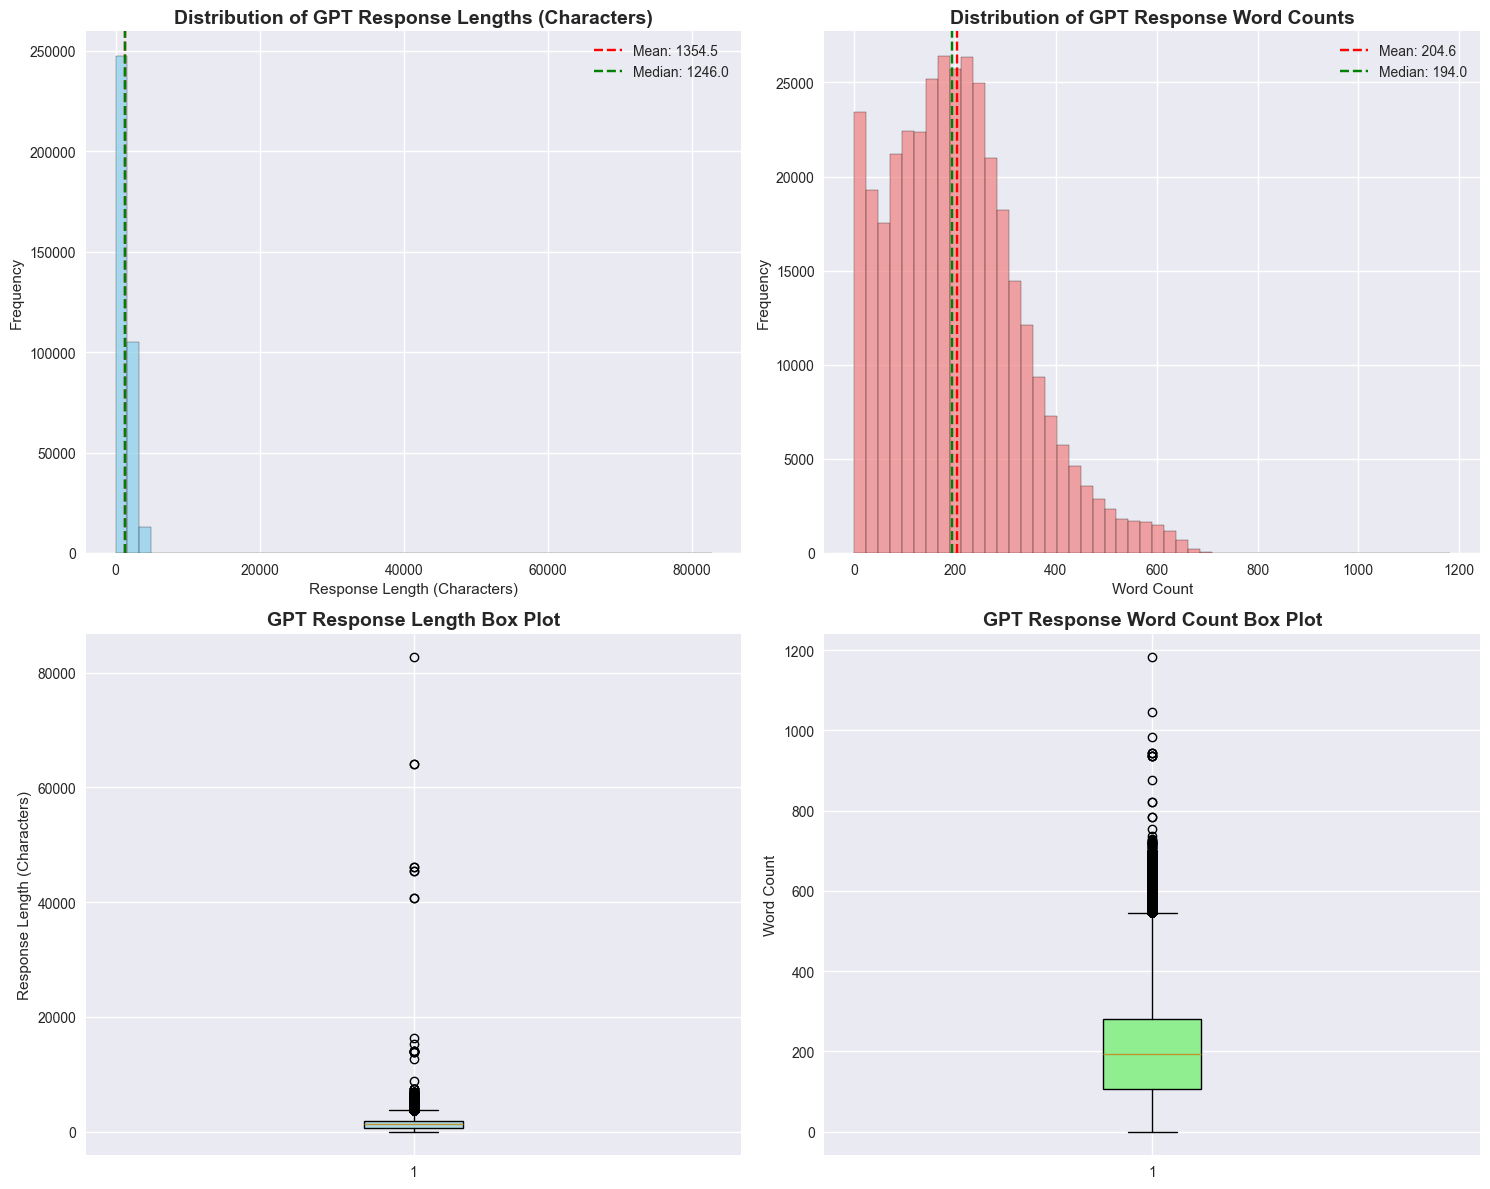

In [5]:
# Visualize GPT response length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Response length histogram
axes[0, 0].hist(gpt_df['response_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of GPT Response Lengths (Characters)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Response Length (Characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(gpt_df['response_length'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {gpt_df["response_length"].mean():.1f}')
axes[0, 0].axvline(gpt_df['response_length'].median(), color='green', linestyle='--', 
                  label=f'Median: {gpt_df["response_length"].median():.1f}')
axes[0, 0].legend()

# Word count histogram
axes[0, 1].hist(gpt_df['word_count'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of GPT Response Word Counts', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(gpt_df['word_count'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {gpt_df["word_count"].mean():.1f}')
axes[0, 1].axvline(gpt_df['word_count'].median(), color='green', linestyle='--', 
                  label=f'Median: {gpt_df["word_count"].median():.1f}')
axes[0, 1].legend()

# Box plot for response lengths
axes[1, 0].boxplot(gpt_df['response_length'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title('GPT Response Length Box Plot', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Response Length (Characters)')

# Box plot for word counts
axes[1, 1].boxplot(gpt_df['word_count'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1, 1].set_title('GPT Response Word Count Box Plot', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()


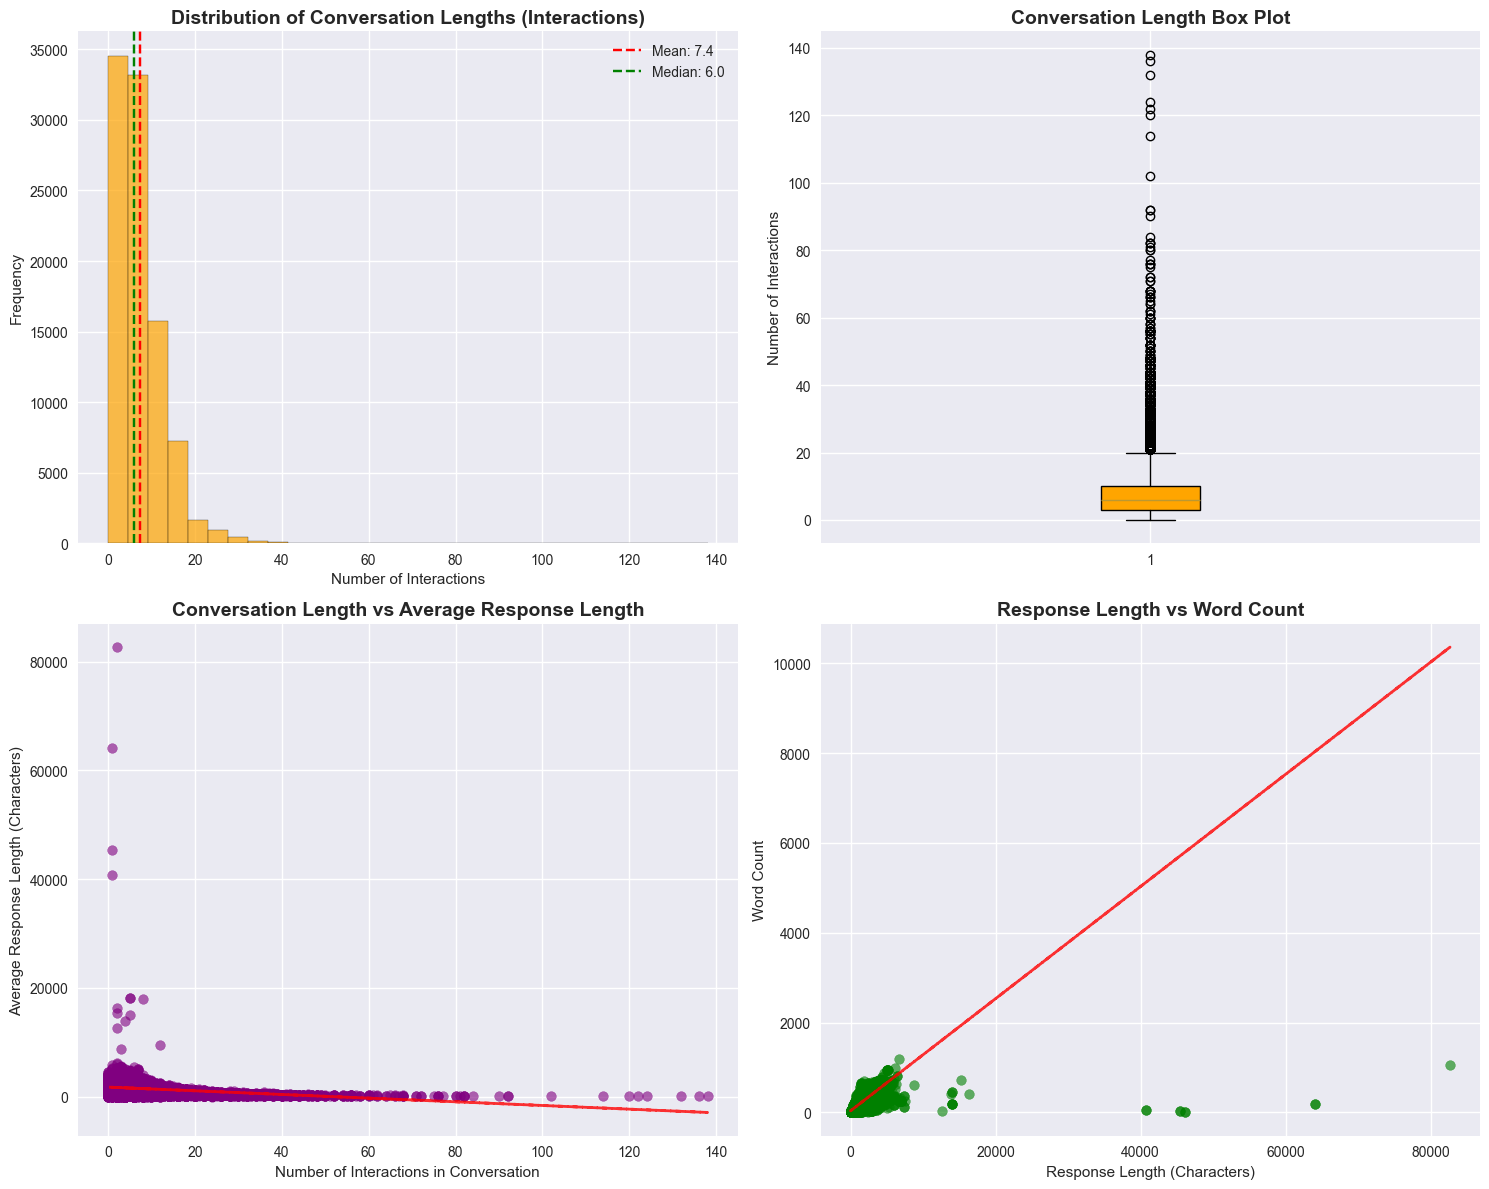

In [6]:
# Analyze conversation lengths and interaction patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Conversation length distribution
axes[0, 0].hist(conversation_df['interaction_count'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0, 0].set_title('Distribution of Conversation Lengths (Interactions)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Interactions')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(conversation_df['interaction_count'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {conversation_df["interaction_count"].mean():.1f}')
axes[0, 0].axvline(conversation_df['interaction_count'].median(), color='green', linestyle='--', 
                  label=f'Median: {conversation_df["interaction_count"].median():.1f}')
axes[0, 0].legend()

# Box plot for conversation lengths
axes[0, 1].boxplot(conversation_df['interaction_count'], patch_artist=True, boxprops=dict(facecolor='orange'))
axes[0, 1].set_title('Conversation Length Box Plot', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Number of Interactions')

# Scatter plot: Conversation length vs Average response length
# Calculate average response length per conversation
avg_response_per_conv = gpt_df.groupby('conversation_id')['response_length'].mean().reset_index()
avg_response_per_conv = avg_response_per_conv.merge(conversation_df, on='conversation_id')

axes[1, 0].scatter(avg_response_per_conv['interaction_count'], avg_response_per_conv['response_length'], 
                   alpha=0.6, color='purple')
axes[1, 0].set_title('Conversation Length vs Average Response Length', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Interactions in Conversation')
axes[1, 0].set_ylabel('Average Response Length (Characters)')

# Add trend line
z = np.polyfit(avg_response_per_conv['interaction_count'], avg_response_per_conv['response_length'], 1)
p = np.poly1d(z)
axes[1, 0].plot(avg_response_per_conv['interaction_count'], p(avg_response_per_conv['interaction_count']), 
                "r--", alpha=0.8, linewidth=2)

# Response length vs Word count correlation
axes[1, 1].scatter(gpt_df['response_length'], gpt_df['word_count'], alpha=0.6, color='green')
axes[1, 1].set_title('Response Length vs Word Count', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Response Length (Characters)')
axes[1, 1].set_ylabel('Word Count')

# Add trend line
z = np.polyfit(gpt_df['response_length'], gpt_df['word_count'], 1)
p = np.poly1d(z)
axes[1, 1].plot(gpt_df['response_length'], p(gpt_df['response_length']), 
                "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()


In [7]:
# Calculate average response length per conversation
print("Calculating average response length per conversation...")

# Group by conversation and calculate statistics
conversation_stats = gpt_df.groupby('conversation_id').agg({
    'response_length': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'word_count': ['mean', 'median']
}).round(2)

# Flatten column names
conversation_stats.columns = ['_'.join(col).strip() for col in conversation_stats.columns]
conversation_stats = conversation_stats.reset_index()

print(f"Conversation-level statistics calculated for {len(conversation_stats)} conversations")

# Display summary statistics
print(f"\nAverage Response Length per Conversation:")
print(f"Mean: {conversation_stats['response_length_mean'].mean():.2f} characters")
print(f"Median: {conversation_stats['response_length_mean'].median():.2f} characters")
print(f"Standard Deviation: {conversation_stats['response_length_mean'].std():.2f} characters")

print(f"\nAverage Word Count per Conversation:")
print(f"Mean: {conversation_stats['word_count_mean'].mean():.2f} words")
print(f"Median: {conversation_stats['word_count_mean'].median():.2f} words")

# Show top 10 conversations with longest average responses
print(f"\nTop 10 conversations with longest average responses:")
top_conversations = conversation_stats.nlargest(10, 'response_length_mean')[['conversation_id', 'response_length_mean', 'word_count_mean']]
print(top_conversations)


Calculating average response length per conversation...
Conversation-level statistics calculated for 93256 conversations

Average Response Length per Conversation:
Mean: 1486.95 characters
Median: 1401.38 characters
Standard Deviation: 897.75 characters

Average Word Count per Conversation:
Mean: 222.04 words
Median: 213.00 words

Top 10 conversations with longest average responses:
      conversation_id  response_length_mean  word_count_mean
87831       vzBzoKr_0              82687.00          1046.00
67048       hofVjsf_7              64119.00           187.00
25796      FukdN2g_11              45398.00            22.00
54410      ZuXqRSg_55              40788.00            59.00
21613      DOMt0kp_29              18051.67           412.00
91009      yHJutZH_29              18051.67           412.00
67047       hofVjsf_0              17975.50           357.25
58828       cguqZGK_0              16282.00           404.00
48764       Vjs55VZ_0              15293.00           728.00
5440

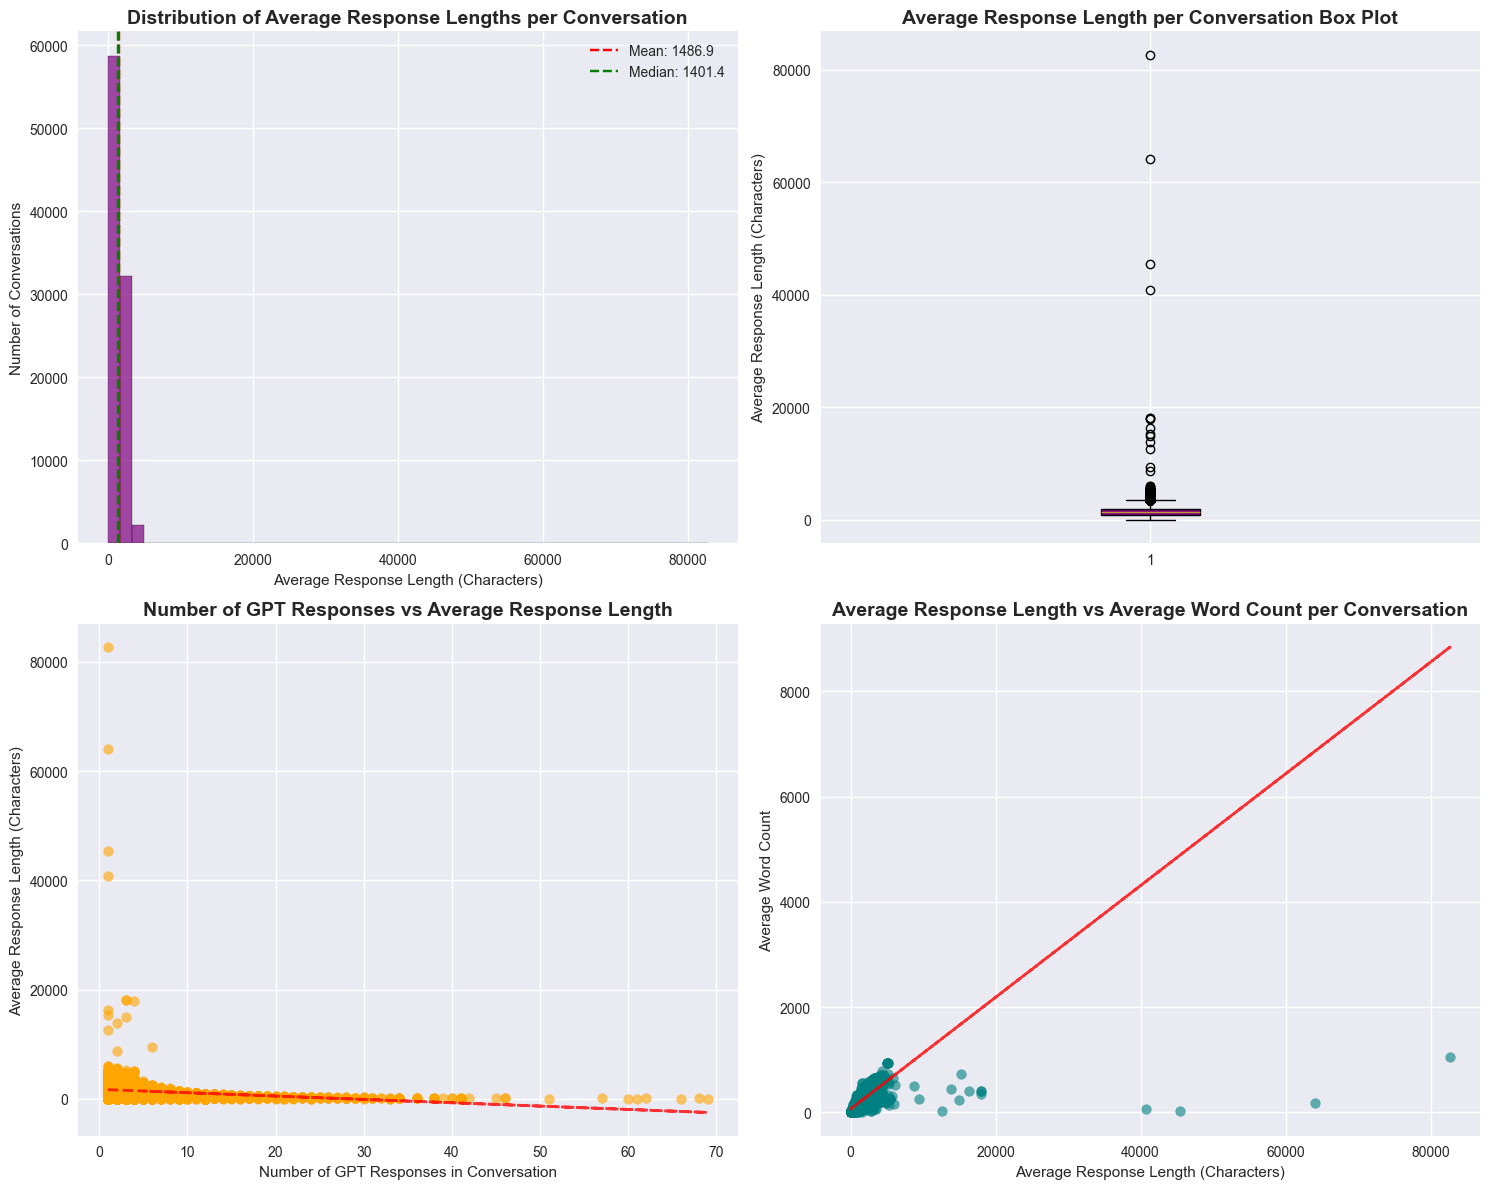

In [8]:
# Visualize average response length per conversation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram of average response lengths per conversation
axes[0, 0].hist(conversation_stats['response_length_mean'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[0, 0].set_title('Distribution of Average Response Lengths per Conversation', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Average Response Length (Characters)')
axes[0, 0].set_ylabel('Number of Conversations')
axes[0, 0].axvline(conversation_stats['response_length_mean'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {conversation_stats["response_length_mean"].mean():.1f}')
axes[0, 0].axvline(conversation_stats['response_length_mean'].median(), color='green', linestyle='--', 
                  label=f'Median: {conversation_stats["response_length_mean"].median():.1f}')
axes[0, 0].legend()

# Box plot of average response lengths per conversation
axes[0, 1].boxplot(conversation_stats['response_length_mean'], patch_artist=True, boxprops=dict(facecolor='purple'))
axes[0, 1].set_title('Average Response Length per Conversation Box Plot', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average Response Length (Characters)')

# Scatter plot: Number of interactions vs Average response length
axes[1, 0].scatter(conversation_stats['response_length_count'], conversation_stats['response_length_mean'], 
                   alpha=0.6, color='orange')
axes[1, 0].set_title('Number of GPT Responses vs Average Response Length', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of GPT Responses in Conversation')
axes[1, 0].set_ylabel('Average Response Length (Characters)')

# Add trend line
z = np.polyfit(conversation_stats['response_length_count'], conversation_stats['response_length_mean'], 1)
p = np.poly1d(z)
axes[1, 0].plot(conversation_stats['response_length_count'], p(conversation_stats['response_length_count']), 
                "r--", alpha=0.8, linewidth=2)

# Average response length vs Average word count
axes[1, 1].scatter(conversation_stats['response_length_mean'], conversation_stats['word_count_mean'], 
                   alpha=0.6, color='teal')
axes[1, 1].set_title('Average Response Length vs Average Word Count per Conversation', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Response Length (Characters)')
axes[1, 1].set_ylabel('Average Word Count')

# Add trend line
z = np.polyfit(conversation_stats['response_length_mean'], conversation_stats['word_count_mean'], 1)
p = np.poly1d(z)
axes[1, 1].plot(conversation_stats['response_length_mean'], p(conversation_stats['response_length_mean']), 
                "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()


In [9]:
# Summary statistics and insights
print("="*60)
print("SHAREGPT DATASET ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 Dataset Overview:")
print(f"   • Total conversations: {len(conversation_ids):,}")
print(f"   • Total GPT responses: {len(gpt_responses):,}")
print(f"   • Total human messages: {len(human_messages):,}")

print(f"\n💬 GPT Response Analysis:")
print(f"   • Average response length: {gpt_df['response_length'].mean():.1f} characters")
print(f"   • Average response word count: {gpt_df['word_count'].mean():.1f} words")
print(f"   • Shortest response: {gpt_df['response_length'].min()} characters")
print(f"   • Longest response: {gpt_df['response_length'].max()} characters")
print(f"   • Median response length: {gpt_df['response_length'].median():.1f} characters")

print(f"\n🗣️ Conversation Analysis:")
print(f"   • Average interactions per conversation: {conversation_df['interaction_count'].mean():.2f}")
print(f"   • Shortest conversation: {conversation_df['interaction_count'].min()} interactions")
print(f"   • Longest conversation: {conversation_df['interaction_count'].max()} interactions")
print(f"   • Median interactions per conversation: {conversation_df['interaction_count'].median():.1f}")

print(f"\n📈 Average Response Length per Conversation:")
print(f"   • Mean: {conversation_stats['response_length_mean'].mean():.1f} characters")
print(f"   • Median: {conversation_stats['response_length_mean'].median():.1f} characters")
print(f"   • Standard Deviation: {conversation_stats['response_length_mean'].std():.1f} characters")
print(f"   • Shortest average: {conversation_stats['response_length_mean'].min():.1f} characters")
print(f"   • Longest average: {conversation_stats['response_length_mean'].max():.1f} characters")

print(f"\n🔗 Key Insights:")
print(f"   • Average response length per conversation: {conversation_stats['response_length_mean'].mean():.1f} characters")
print(f"   • Average word count per conversation: {conversation_stats['word_count_mean'].mean():.1f} words")
print(f"   • Response length varies significantly across conversations")
print(f"   • Strong correlation between response length and word count")

print("\n" + "="*60)


SHAREGPT DATASET ANALYSIS SUMMARY

📊 Dataset Overview:
   • Total conversations: 94,145
   • Total GPT responses: 365,184
   • Total human messages: 331,410

💬 GPT Response Analysis:
   • Average response length: 1354.5 characters
   • Average response word count: 204.6 words
   • Shortest response: 0 characters
   • Longest response: 82687 characters
   • Median response length: 1246.0 characters

🗣️ Conversation Analysis:
   • Average interactions per conversation: 7.40
   • Shortest conversation: 0 interactions
   • Longest conversation: 138 interactions
   • Median interactions per conversation: 6.0

📈 Average Response Length per Conversation:
   • Mean: 1486.9 characters
   • Median: 1401.4 characters
   • Standard Deviation: 897.7 characters
   • Shortest average: 0.0 characters
   • Longest average: 82687.0 characters

🔗 Key Insights:
   • Average response length per conversation: 1486.9 characters
   • Average word count per conversation: 222.0 words
   • Response length varies